# Introduction: The steady-state Kalman filter
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It shows how to implement a steady-state Kalman filter.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

% Load the control package for the "dlqe" command
pkg load control

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Implementing a steady-state Kalman filter
The next notebook cells implement the standard Kalman filter and the steady-state Kalman filter.

In [3]:
% Initialize simulation variables
[nx,nt] = size(x); 

xhat = zeros(nx,1);     % Initialize Kalman filter initial estimate
xhatss = zeros(nx,1);   % Initialize Kalman filter initial estimate
SigmaX = zeros(nx,nx);  % Initialize Kalman filter covariance

% Reserve storage for variables we might want to plot/evaluate
xhatstore = zeros(nx,nt);
xhatssstore = zeros(nx,nt);
boundstore = xhatstore;
Lstore = zeros(nx,nt);
SigmaXstore = zeros(nx,nx,nt);
SigmaXMstore = zeros(nx,nx,nt);
xhatstore(:,1) = xhat;
xhatssstore(:,1) = xhat;
SigmaXstore(:,:,1) = SigmaX;
SigmaXMstore(:,:,1) = SigmaX;

[Lss,SigmaMss,SigmaPss] = dlqe(Ad,eye(2),Cd,SigmaW,SigmaV);

In [4]:
% Now, implement the standard and steady-state Kalman filters
for k = 2:nt
  % KF Step 1a: State prediction time update      
  xhat = Ad*xhat + Bd*u(:,k-1); % use prior value of "u"
  xhatss = Ad*xhatss + Bd*u(:,k-1); % use prior value of "u"

  % KF Step 1b: Prediction-error covariance time update
  SigmaX = Ad*SigmaX*Ad' + SigmaW;

  % Store prediction covariance
  SigmaXMstore(:,:,k) = SigmaX;

  % KF Step 1c: Estimate system output
  zhat = Cd*xhat + Dd*u(k);
  zhatss = Cd*xhatss + Dd*u(k);

  % KF Step 2a: Compute Kalman gain matrix
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
  Lstore(:,k) = L;

  % KF Step 2b: State estimate measurement update
  xhat = xhat + L*(z(k) - zhat);
  xhatss = xhatss + Lss*(z(k) - zhatss);

  % KF Step 2c: Estimation-error covariance measurement update
  SigmaX = SigmaX - L*Cd*SigmaX;

  % Store estimate data for smoothing and KF output
  SigmaXstore(:,:,k) = SigmaX;
  xhatstore(:,k) = xhat;
  xhatssstore(:,k) = xhatss;
  boundstore(:,k) = 3*sqrt(diag(SigmaX));
end

boundssstore = repmat(3*sqrt(diag(SigmaPss)),1,nt);

### Plot simulation outputs 
The next notebook cells plot variables from the standard Kalman filter and the steady-state Kalman filter.

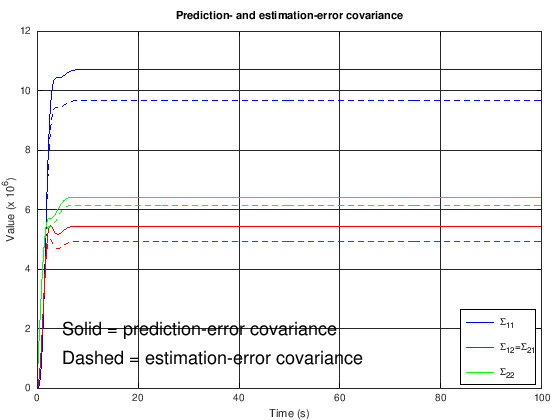

In [5]:
% Plot the elements of the time-varying covariance matrices in the standard Kalman filter
h1 = plot(t,1e6*squeeze(SigmaXMstore(1,1,:)),'b-'); hold on; 
plot(t,1e6*squeeze(SigmaXstore(1,1,:)),'b--'); grid on;
h2 = plot(t,1e6*squeeze(SigmaXMstore(1,2,:)),'r-'); 
plot(t,1e6*squeeze(SigmaXstore(1,2,:)),'r--');
h3 = plot(t,1e6*squeeze(SigmaXMstore(2,2,:)),'g-'); 
plot(t,1e6*squeeze(SigmaXstore(2,2,:)),'g--');
title('Prediction- and estimation-error covariance')
ylabel('Value (x 10^6)')
xlabel('Time (s)')
warning off % disable warnings from Octave for the Sigma character, which seems to render properly
legend([h1,h2,h3],'\Sigma_{11}','\Sigma_{12}=\Sigma_{21}','\Sigma_{22}','location','southeast')
warning on % re-enable warnings
text(5,1,'Dashed = estimation-error covariance','fontsize',18)
text(5,2,'Solid = prediction-error covariance','fontsize',18)

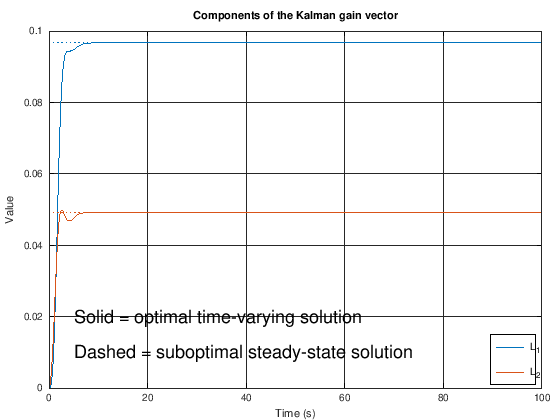

In [6]:
% Plot the time-varying Kalman gain from the standard Kalman filter, 
% overlaid with the steady-state Kalman gain
h1 = plot(t,Lstore); grid on; hold on
set(gca,"ColorOrderIndex",1);
plot(t,repmat(Lss,1,nt),':');
title('Components of the Kalman gain vector');
ylabel('Value')
xlabel('Time (s)')
legend('L_1','L_2','location','southeast')
text(5,0.01,'Dashed = suboptimal steady-state solution','fontsize',18)
text(5,0.02,'Solid = optimal time-varying solution','fontsize',18)

rmse1 =  0.0030176
rmse2 =  0.0030447
rmse3 =  0.0023656
rmse4 =  0.0023705


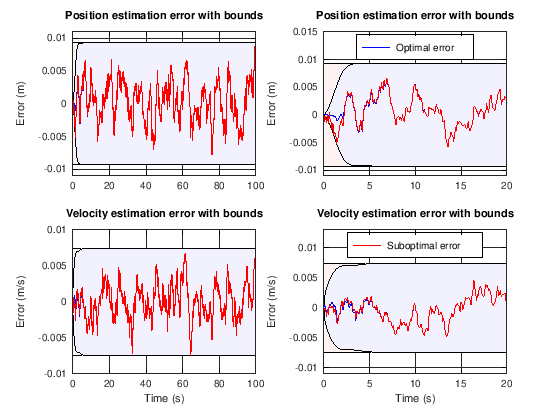

In [7]:
% Plot estimation errors over the entire dataset

xerr = x - xhatstore; xsserr = x - xhatssstore; 
subplot(2,2,1); 
fill([t fliplr(t)],[-boundssstore(1,:) fliplr(boundssstore(1,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b',t,xsserr(1,:),'r'); ylim([-0.011 0.011]);
title('Position estimation error with bounds'); ylabel('Error (m)'); 

subplot(2,2,3); 
fill([t fliplr(t)],[-boundssstore(2,:) fliplr(boundssstore(2,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b',t,xsserr(2,:),'r');
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 

% Now, plot zoomed-in figures

subplot(2,2,2); 
fill([t fliplr(t)],[-boundssstore(1,:) fliplr(boundssstore(1,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
h1 = plot(t,xerr(1,:),'b',t,xsserr(1,:),'r'); ylim([-0.011 0.015]);
title('Position estimation error with bounds'); ylabel('Error (m)'); 
legend(h1(1),'Optimal error','location','north')
rmse1 = rms(xerr(1,:))
rmse2 = rms(xsserr(1,:))
xlim([0 20]);

subplot(2,2,4); 
fill([t fliplr(t)],[-boundssstore(2,:) fliplr(boundssstore(2,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
h1 = plot(t,xerr(2,:),'b',t,xsserr(2,:),'r'); ylim([-0.011 0.013]);
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
legend(h1(2),'Suboptimal error','location','north')
rmse3 = rms(xerr(2,:))
rmse4 = rms(xsserr(2,:))
xlim([0 20]);